In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

%matplotlib inline
sns.set_style('whitegrid')



In [7]:
# Define regulated hours as constants
START_TIME = pd.to_datetime('08:00').time()
END_TIME = pd.to_datetime('20:00').time()

def create_slot_index(timestamp):
    """
    Calculate the slot index for a given timestamp.
    
    Parameters:
      timestamp (datetime-like): A Pandas Timestamp or datetime object.
    
    Returns:
      int: Slot index (0 to 143) if the time is within regulated hours (08:00 to 20:00),
           otherwise returns -1 (or np.nan if preferred).
    """
    time_of_day = timestamp.time()
    
    # Include times starting at 08:00 and before 20:00
    if START_TIME <= time_of_day < END_TIME:
        minutes_since_start = (timestamp.hour - 8) * 60 + timestamp.minute
        slot_index = minutes_since_start // 5
        return slot_index
    else:
        return -1  # or np.nan

# Test the function with a sample timestamp
test_timestamp = pd.to_datetime("2025-01-01 09:30")
print("Test slot index:", create_slot_index(test_timestamp))


Test slot index: 18


In [12]:
import pandas as pd

# Define the function to calculate the slot index.  THIS IS CRUCIAL!
def create_slot_index(dt):
    """
    Calculates the slot index for a given datetime.

    Assumes slots are 15 minutes long, starting at midnight.
    Slot 0: 00:00 - 00:14:59.999...
    Slot 1: 00:15 - 00:29:59.999...
    ...
    Slot 95: 23:45 - 23:59:59.999...

    Args:
        dt: A datetime object (timezone-aware).

    Returns:
        The integer slot index (0-95).
    """
    return (dt.hour * 4) + (dt.minute // 15)

# Define the path to your feature-engineered CSV file
csv_path = "/Users/adrianiraeguialvear/OnSpot_Predictive_Model/data/feature_engineered_data.csv"

# Load the CSV file into a DataFrame
df = pd.read_csv(csv_path)

# Convert the 'datetime' column to datetime objects.
df['datetime'] = pd.to_datetime(df['datetime'])

# Handle timezone localization and conversion more robustly.
# The original code's `if` statement is correct, but this is more explicit.
if df['datetime'].dt.tz is None:
    # Localize as UTC if no timezone is set.
    df['datetime'] = df['datetime'].dt.tz_localize('UTC')

# Convert timestamps from UTC to the desired timezone (Europe/Madrid)
df['datetime_local'] = df['datetime'].dt.tz_convert('Europe/Madrid')

# Calculate the slot index based on the localized datetime,
# now that create_slot_index is defined.
df['calculated_slot_index'] = df['datetime_local'].apply(create_slot_index)

# Display the first few rows to verify the new columns
print(df[['datetime_local', 'calculated_slot_index']].head())
print(df[['datetime', 'calculated_slot_index']].head())

# --- Verification and Example ---
# Let's test with some specific datetimes to make sure it's working as expected.

# Example 1:  10:17 AM in Madrid
test_dt1 = pd.Timestamp("2024-01-01 10:17:00+01:00", tz='Europe/Madrid')
slot1 = create_slot_index(test_dt1)
print(f"Test 1: {test_dt1} -> Slot {slot1}")  # Expected: Slot 41

# Example 2: 23:59 UTC, convert to Madrid
test_dt2_utc = pd.Timestamp("2024-01-01 23:59:00+00:00", tz='UTC')
test_dt2_madrid = test_dt2_utc.tz_convert('Europe/Madrid')
slot2 = create_slot_index(test_dt2_madrid)
print(f"Test 2: {test_dt2_utc} -> {test_dt2_madrid} -> Slot {slot2}")  # Expected: Slot 0 (because it becomes the next day)

# Example 3: Midnight in Madrid
test_dt3 = pd.Timestamp("2024-03-01 00:00:00+01:00", tz='Europe/Madrid')
slot3 = create_slot_index(test_dt3)
print(f"Test 3: {test_dt3} -> Slot {slot3}")  # Expected: Slot 0

# Example 4: Just before a slot change
test_dt4 = pd.Timestamp("2024-03-01 00:14:59+01:00", tz='Europe/Madrid')
slot4 = create_slot_index(test_dt4)
print(f"Test 4: {test_dt4} -> Slot {slot4}") #Expected : Slot 0

# Example 5: Right at slot change
test_dt5 = pd.Timestamp("2024-03-01 00:15:00+01:00", tz='Europe/Madrid')
slot5 = create_slot_index(test_dt5)
print(f"Test 5: {test_dt5} -> Slot {slot5}") #Expected: Slot 1

             datetime_local  calculated_slot_index
0 2025-01-31 08:00:00+01:00                     32
1 2025-01-31 08:00:00+01:00                     32
2 2025-01-31 08:00:00+01:00                     32
3 2025-01-31 08:00:00+01:00                     32
4 2025-01-31 08:00:00+01:00                     32
                   datetime  calculated_slot_index
0 2025-01-31 07:00:00+00:00                     32
1 2025-01-31 07:00:00+00:00                     32
2 2025-01-31 07:00:00+00:00                     32
3 2025-01-31 07:00:00+00:00                     32
4 2025-01-31 07:00:00+00:00                     32
Test 1: 2024-01-01 10:17:00+01:00 -> Slot 41
Test 2: 2024-01-01 23:59:00+00:00 -> 2024-01-02 00:59:00+01:00 -> Slot 3
Test 3: 2024-03-01 00:00:00+01:00 -> Slot 0
Test 4: 2024-03-01 00:14:59+01:00 -> Slot 0
Test 5: 2024-03-01 00:15:00+01:00 -> Slot 1


In [5]:
# Check the DataFrame structure and summary statistics
print(df.info())
print(df.describe())

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1596000 entries, 0 to 1595999
Data columns (total 24 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   _id               1596000 non-null  object 
 1   id_tramo          1596000 non-null  int64  
 2   tramo             1596000 non-null  object 
 3   tipo              1596000 non-null  object 
 4   tarifa            1596000 non-null  object 
 5   horario           1596000 non-null  object 
 6   lon               1596000 non-null  float64
 7   lat               1596000 non-null  float64
 8   time_slot         1596000 non-null  int64  
 9   occupancy_level   1596000 non-null  int64  
 10  datetime          1596000 non-null  object 
 11  hour              1596000 non-null  int64  
 12  day_of_week       1596000 non-null  int64  
 13  month             1596000 non-null  int64  
 14  minute            1596000 non-null  int64  
 15  slot_index        1596000 non-null  int64  
 16  

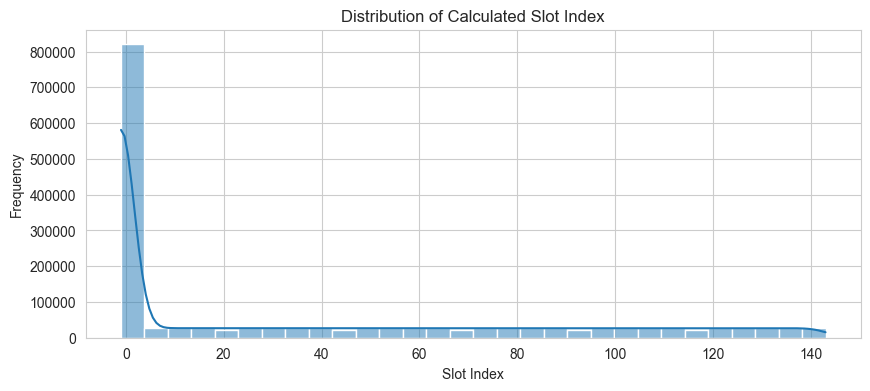

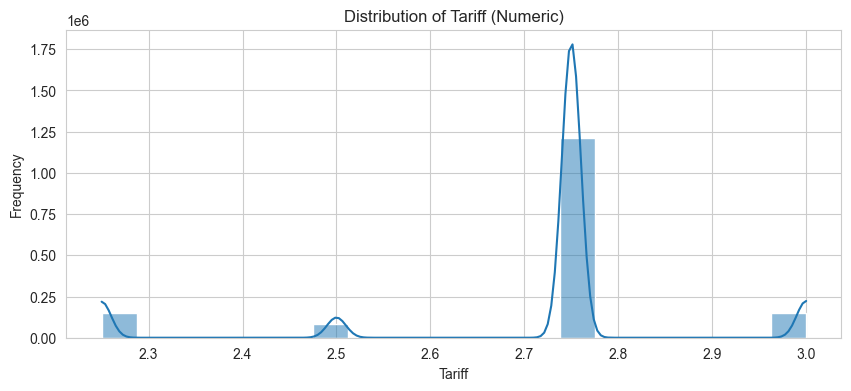

In [14]:
# Histogram of slot_index to see distribution of time slots
plt.figure(figsize=(10, 4))
sns.histplot(df['calculated_slot_index'], bins=30, kde=True)
plt.title("Distribution of Calculated Slot Index")
plt.xlabel("Slot Index")
plt.ylabel("Frequency")
plt.show()

# If tariff_numeric is present, plot its distribution
if 'tariff_numeric' in df.columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(df['tariff_numeric'], bins=20, kde=True)
    plt.title("Distribution of Tariff (Numeric)")
    plt.xlabel("Tariff")
    plt.ylabel("Frequency")
    plt.show()


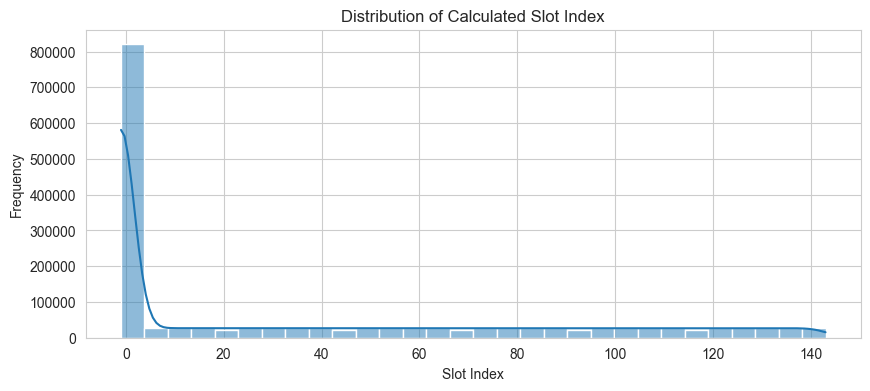

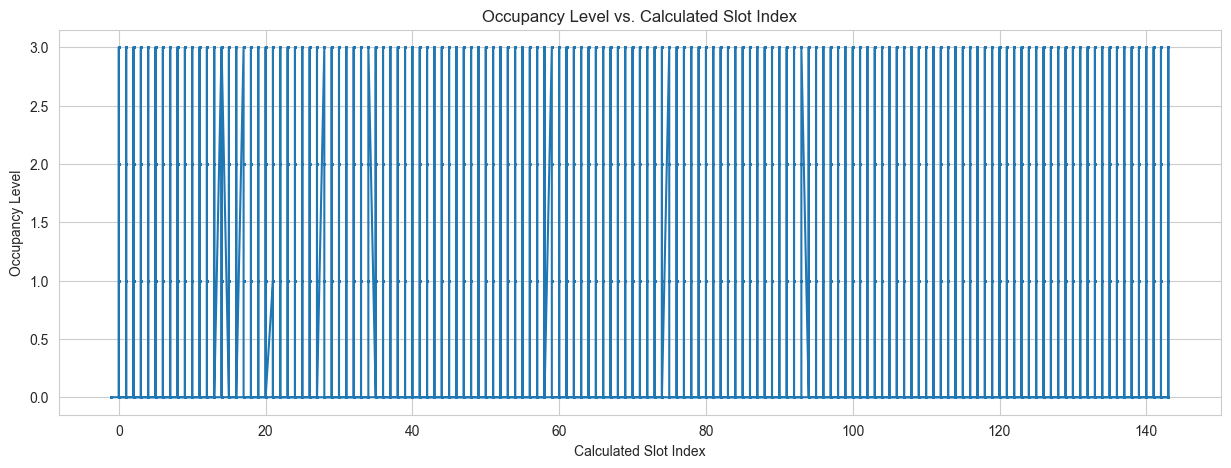

In [15]:
plt.figure(figsize=(10, 4))
sns.histplot(df['calculated_slot_index'], bins=30, kde=True)
plt.title("Distribution of Calculated Slot Index")
plt.xlabel("Slot Index")
plt.ylabel("Frequency")
plt.show()


# Plot cyclical features to confirm daily patterns
plt.figure(figsize=(15, 5))
plt.plot(df['calculated_slot_index'], df['occupancy_level'], marker='.', linestyle='-', markersize=2)
plt.title("Occupancy Level vs. Calculated Slot Index")
plt.xlabel("Calculated Slot Index")
plt.ylabel("Occupancy Level")
plt.show()



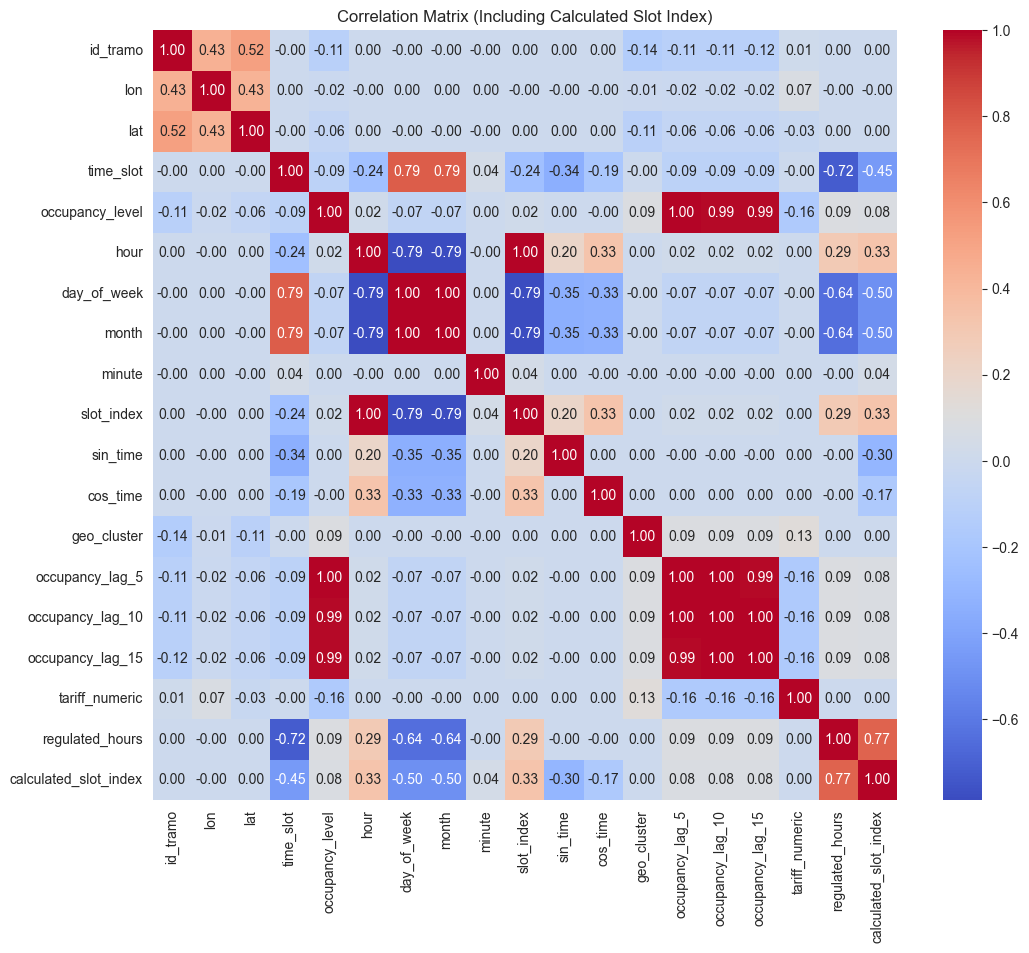

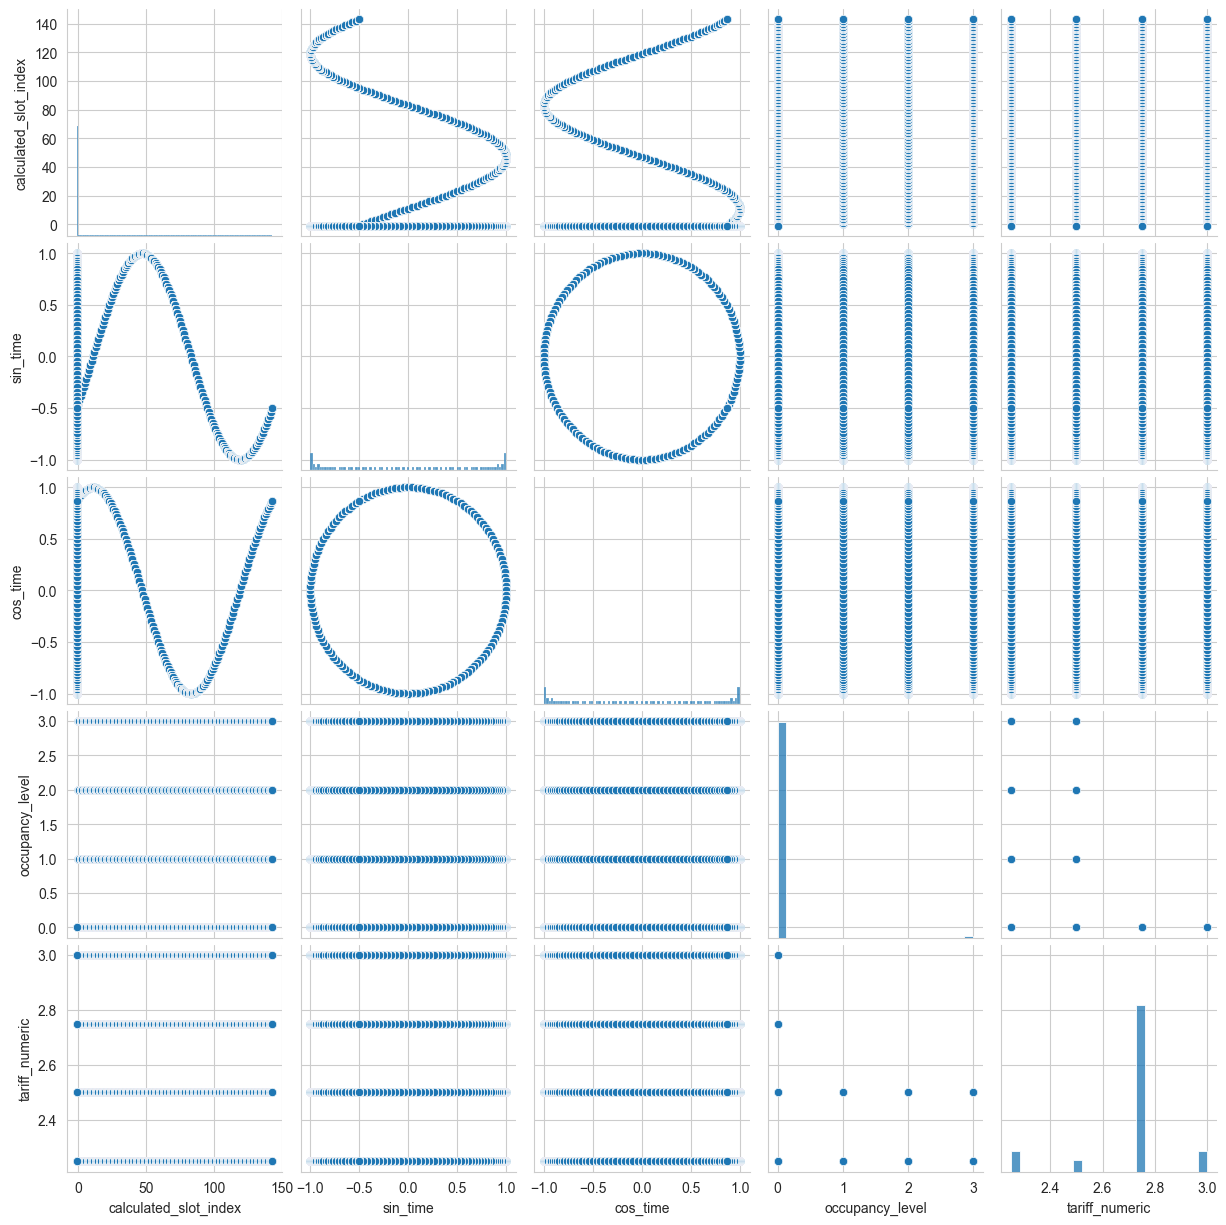

In [16]:
# Compute and display the correlation matrix
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 10))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix (Including Calculated Slot Index)")
plt.show()


# Optionally, use pairplots to inspect pairwise relationships among key features
features = ['calculated_slot_index', 'sin_time', 'cos_time', 'occupancy_level', 'tariff_numeric']

# Create a pairplot for the selected features.
# dropna() is used to remove rows with missing values in these columns.
sns.pairplot(df[features].dropna())

# Display the plot
plt.show()

In [9]:
import folium

# Create a base map centered on Barcelona (approximate coordinates)
base_map = folium.Map(location=[41.3851, 2.1734], zoom_start=12)

# Add markers for each parking zone
for _, row in df.iterrows():
    if pd.notnull(row['lat']) and pd.notnull(row['lon']):
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=3,
            popup=f"Occupancy: {row['occupancy_level']}",
            color='blue',
            fill=True,
            fill_color='blue'
        ).add_to(base_map)

# Save and display the map (the map will be saved as an HTML file)
base_map.save("parking_zones_map.html")
print("Map saved as parking_zones_map.html")


Map saved as parking_zones_map.html


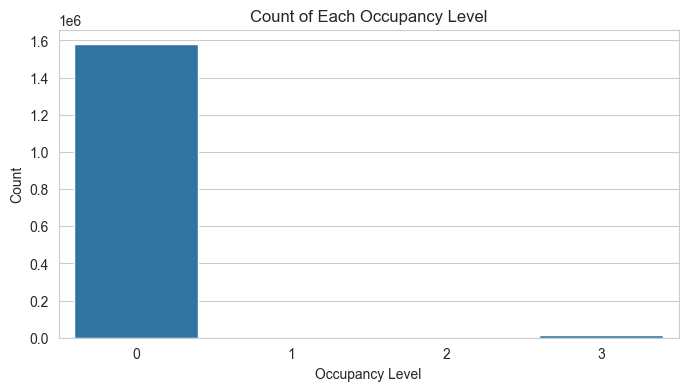

In [11]:
# Count of each occupancy_level
plt.figure(figsize=(8, 4))
sns.countplot(x='occupancy_level', data=df)
plt.title("Count of Each Occupancy Level")
plt.xlabel("Occupancy Level")
plt.ylabel("Count")
plt.show()


In [17]:
# Time Series for a Specific Zone (Zoomed-in - e.g., first 3 days)
zone_id_to_plot = 1  # Choose a zone ID to inspect
zone_df_sample = df[(df['zone_id_encoded'] == zone_id_to_plot) & (df['datetime'] < df['datetime'].min() + pd.Timedelta(days=3))].copy() # Sample first 3 days

plt.figure(figsize=(12, 6))
plt.plot(zone_df_sample['datetime'], zone_df_sample['occupancy_level'], label=f'Zone ID: {zone_id_to_plot}')
plt.xlabel('Timestamp')
plt.ylabel('Occupancy Level')
plt.title(f'Time Series of Parking Availability Level (Zoomed-in) for Zone ID {zone_id_to_plot}')
plt.legend()
plt.grid(True)
plt.show()

# Aggregate Availability Level (e.g., Mean) across All Zones - Time Series
aggregated_df = df.groupby('datetime')['occupancy_level'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(aggregated_df['datetime'], aggregated_df['occupancy_level'], label='Average Occupancy Level (All Zones)')
plt.xlabel('Timestamp')
plt.ylabel('Average Occupancy Level')
plt.title('Time Series of Average Parking Availability Level (All Zones)')
plt.legend()
plt.grid(True)
plt.show()

KeyError: 'zone_id_encoded'

In [ ]:
# Box plot by hour of day (for multiple zones or all zones)
plt.figure(figsize=(12, 7))
sns.boxplot(x='hour', y='occupancy_level', data=df) # You can add hue='zone_id_encoded' to compare zones if needed
plt.title('Box Plot of Occupancy Level by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Occupancy Level')
plt.show()

# Violin plot by day of week (for multiple zones or all zones)
plt.figure(figsize=(12, 7))
sns.violinplot(x='day_of_week', y='occupancy_level', data=df) # You can add hue='zone_id_encoded' to compare zones
plt.title('Violin Plot of Occupancy Level by Day of Week')
plt.xlabel('Day of Week (0=Mon, 4=Fri)')
plt.ylabel('Occupancy Level')
plt.show()

In [ ]:
# Pivot table to get average occupancy level for each hour and day of week
hourly_weekday_avg_occupancy = df.pivot_table(values='occupancy_level', index='hour', columns='day_of_week', aggfunc='mean')

plt.figure(figsize=(10, 8))
sns.heatmap(hourly_weekday_avg_occupancy, annot=True, fmt=".2f", cmap="YlGnBu") # annot=True to show values, cmap for color scheme
plt.title('Heatmap of Average Occupancy Level by Hour of Day and Day of Week')
plt.xlabel('Day of Week (0=Mon, 4=Fri)')
plt.ylabel('Hour of Day')
plt.yticks(rotation=0) # Keep y-axis labels horizontal
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average occupancy level per zone
zone_avg_occupancy = df.groupby(['zone_id_encoded', 'lon', 'lat'])['occupancy_level'].mean().reset_index() # Group by zone ID and lat/long

plt.figure(figsize=(10, 10))
scatter = plt.scatter(zone_avg_occupancy['lon'], zone_avg_occupancy['lat'],
                        c=zone_avg_occupancy['occupancy_level'], cmap='viridis', s=100, alpha=0.7) # s for size, alpha for transparency
plt.colorbar(scatter, label='Average Occupancy Level')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Spatial Scatter Plot of Average Parking Occupancy Levels per Zone')
plt.grid(True)
plt.show()

In [ ]:
numerical_features = ['slot_index', 'sin_time', 'cos_time', 'tariff_numeric'] # Add other numerical features

for feature in numerical_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[feature], kde=True) # kde=True for kernel density estimate
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

In [ ]:
numerical_features_vs_target = ['tariff_numeric'] # Add relevant numerical features

for feature in numerical_features_vs_target:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='occupancy_level', y=feature, data=df) # Or use violinplot
    plt.xlabel('Occupancy Level')
    plt.ylabel(feature)
    plt.title(f'Box Plot of {feature} by Occupancy Level')
    plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix for a subset of features (e.g., temporal + lag)
feature_subset_for_corr = ['slot_index', 'sin_time', 'cos_time', 'day_of_week', 'occupancy_level', 'occupancy_lag_5', 'occupancy_lag_15']

corr_matrix_subset = df[feature_subset_for_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_subset, annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Correlation Matrix (Subset of Features)')
plt.show()

Observations:

The distribution of slot_index shows that our data covers the expected 144 time slots.
The cyclical features (sin_time and cos_time) effectively capture the daily cycle.
Preliminary time series plots suggest peaks in occupancy at [insert observed times].
The correlation matrix highlights a strong relationship between [feature X] and occupancy_level.
Next Steps:

Address any data imbalances noted.
Refine feature selection based on the correlations and pairplots.
Begin prototyping predictive models using these insights.